# Domain 1: which antigens are at risk of falling below their 2024 level? (all LGAs)

**National Primary Health Care Development Agency (NPHCDA) - Predictive Modelling of Zero-Dose Children.**
Prepared by the CIDRE and Quantium Insights LLC consortium, with UNICEF and Gavi.

**Question.** Which routine immunization antigens are projected to fall below 80% of their 2024 delivery level in the next 6 to 12 months, nationally and in each local government area (LGA)?

**Method (unchanged from the Domain 1 analysis).**
1. Monthly doses from DHIS2 (January 2021 to December 2025) are summed nationally and for every LGA.
2. A Prophet time-series model is fitted to each series:
   - yearly seasonality plus a semi-annual cycle;
   - 95% prediction interval;
   - changepoint prior scale 0.05 and seasonality prior scale 10;
   - 18-month horizon.
3. Each forecast is expressed as a percent of that series' own 2024 mean monthly doses.
4. An **early-warning flag** is raised when the forecast falls below 80% in months 6 to 12 after the last observed month, that is June to December 2026.
5. LGA series need at least 18 months of data, some doses, and a 2024 baseline.

**What the flag is, and is not.** It is a decline tripwire: doses are projected to fall below four-fifths of what the same area delivered in 2024. It is not coverage, because no child population enters the calculation. Coverage of the eligible cohort is shown separately in section 7.

**How to run.** Choose Runtime > Run all, and upload the four files from *Updated Datasets for Domain 1* when asked. The LGA step fits about 3,100 models; it takes about 10-20 minutes on Colab.

In [1]:
# ---- Setup: works in Google Colab and locally ------------------------------------------------
import os, sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REQUIRED = ['dhis2_data_all_states.csv', 'dhis2_data_additional_antigens.csv', 'under_5_2024.csv', 'ndhs_antigens2024.csv']

if IN_COLAB:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + ['prophet', 'joblib', 'openpyxl'], check=False)
    DATA_DIR = Path("/content/data"); DATA_DIR.mkdir(exist_ok=True)
    # Option A (default): upload the files from the matching folder of "Updated Datasets for Domain 5".
    # Option B: mount Google Drive and point DATA_DIR at the folder, e.g.
    #   from google.colab import drive; drive.mount("/content/drive")
    #   DATA_DIR = Path("/content/drive/MyDrive/Updated Datasets for Domain 5/<folder>")
    missing = [f for f in REQUIRED if not (DATA_DIR / f).exists()]
    if missing:
        from google.colab import files
        print("Please select these files (you can select them all at once):", missing)
        for name, content in files.upload().items():
            (DATA_DIR / name).write_bytes(content)
else:
    DATA_DIR = Path(os.environ.get("D5_DATA_DIR", ".")).resolve()

OUT_DIR = Path(os.environ.get("D5_OUT_DIR", "outputs")).resolve(); OUT_DIR.mkdir(parents=True, exist_ok=True)
missing = [f for f in REQUIRED if not (DATA_DIR / f).exists()]
assert not missing, f"Missing input files in {DATA_DIR}: {missing}"
print("Data folder:", DATA_DIR.name, "| all", len(REQUIRED), "input files found | outputs ->", OUT_DIR.name)

Data folder: Updated Datasets for Domain 1 | all 4 input files found | outputs -> outputs_D1


## 1. Load the DHIS2 data correctly

DHIS2 exports print counts of 1,000 or more with a thousands separator, for example `"1,234"`.

- **The right way:** read the file with `thousands=","` so these are read as numbers.
- **The wrong way:** reading them as text and then forcing to numbers turns every such value into a missing value. That silently removes the busiest LGA-months and makes those series jump between real values and zero.

In [2]:
import numpy as np, pandas as pd, warnings, logging
warnings.filterwarnings("ignore")
for _l in ("prophet", "cmdstanpy"): logging.getLogger(_l).setLevel(logging.ERROR)
d = pd.read_csv(DATA_DIR / "dhis2_data_all_states.csv", thousands=",", low_memory=False)
d["ds"] = pd.to_datetime(d["period"].astype(str).str.strip(), format="%b-%y")
ANT = {"BCG": "bcg_count", "Penta1": "penta_1_count", "Penta3": "penta_3_count", "Measles1": "measles_1_count"}
for c in ANT.values():
    d[c] = pd.to_numeric(d[c], errors="coerce")
raw = pd.read_csv(DATA_DIR / "dhis2_data_all_states.csv", dtype=str)
n_sep = sum(raw[c].str.contains(",", na=False).sum() for c in ANT.values())
print(f"Rows: {len(d):,} | LGAs: {d.lga.nunique()} | states: {d.state.nunique()} | months: {d.ds.min():%b %Y} to {d.ds.max():%b %Y}")
print(f"Tracer-antigen values written with a thousands separator (now read correctly): {n_sep:,}")
first = d.groupby("state").ds.min()
print("States whose rows start after January 2021:", first[first > d.ds.min()].dt.strftime("%b %Y").to_dict())

Rows: 43,656 | LGAs: 774 | states: 37 | months: Jan 2021 to Dec 2025
Tracer-antigen values written with a thousands separator (now read correctly): 40,627
States whose rows start after January 2021: {'Katsina': 'Jan 2023', 'Kogi': 'Jan 2023', 'Kwara': 'Jan 2023', 'Lagos': 'Jan 2023', 'Niger': 'Jan 2023'}


## 2. National forecasts for the four tracer antigens

In [3]:
from prophet import Prophet
def prophet_fit(df, periods=18):
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, interval_width=0.95,
                changepoint_prior_scale=0.05, seasonality_prior_scale=10)
    m.add_seasonality(name="semi_annual", period=182.5, fourier_order=3)
    m.fit(df)
    return m.predict(m.make_future_dataframe(periods=periods, freq="MS"))

nat = d.groupby("ds")[list(ANT.values())].sum().reset_index()
nat_rows, nat_fc = [], {}
for a, c in ANT.items():
    ts = nat[["ds", c]].rename(columns={c: "y"})
    fc = prophet_fit(ts); cut = ts.ds.max(); base = ts[ts.ds.dt.year == 2024].y.mean()
    fo = fc[fc.ds > cut].copy(); fo["pct"] = fo.yhat / base * 100
    fo["ahead"] = (fo.ds.dt.year - cut.year) * 12 + (fo.ds.dt.month - cut.month)
    win = fo[fo.ahead.between(6, 12)]
    nat_fc[a] = (ts, fc, base)
    nat_rows.append(dict(antigen=a, doses_per_month_2024=round(base), lowest_forecast_pct=round(fo.pct.min(), 1),
                         month=fo.loc[fo.pct.idxmin(), "ds"].strftime("%b %Y"), flag_in_months_6_12=bool((win.pct < 80).any())))
national = pd.DataFrame(nat_rows); national

Importing plotly failed. Interactive plots will not work.


03:05:06 - cmdstanpy - INFO - Chain [1] start processing


03:05:06 - cmdstanpy - INFO - Chain [1] done processing


03:05:06 - cmdstanpy - INFO - Chain [1] start processing


03:05:06 - cmdstanpy - INFO - Chain [1] done processing


03:05:06 - cmdstanpy - INFO - Chain [1] start processing


03:05:07 - cmdstanpy - INFO - Chain [1] done processing


03:05:07 - cmdstanpy - INFO - Chain [1] start processing


03:05:07 - cmdstanpy - INFO - Chain [1] done processing


,antigen,doses_per_month_2024,lowest_forecast_pct,month,flag_in_months_6_12
0,BCG,687698,99.9,Dec 2026,False
1,Penta1,733663,106.5,Sep 2026,False
2,Penta3,682622,107.4,Dec 2026,False
3,Measles1,640314,106.5,Sep 2026,False


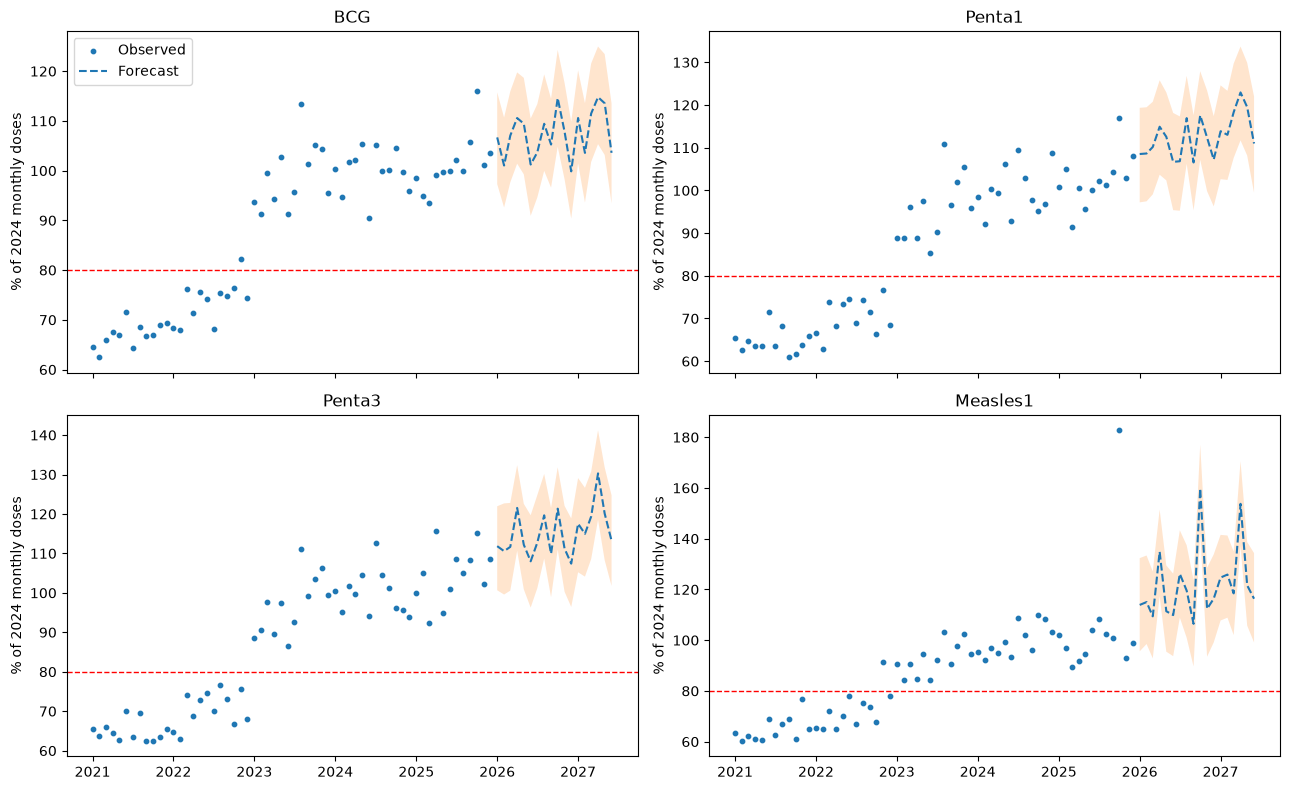

In [4]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, (a, (ts, fc, base)) in zip(axs.flat, nat_fc.items()):
    cut = ts.ds.max(); fo = fc[fc.ds > cut]
    ax.scatter(ts.ds, ts.y / base * 100, s=10, label="Observed")
    ax.plot(fo.ds, fo.yhat / base * 100, "--", label="Forecast")
    ax.fill_between(fo.ds, fo.yhat_lower / base * 100, fo.yhat_upper / base * 100, alpha=0.2)
    ax.axhline(80, color="red", ls="--", lw=1); ax.set_title(a); ax.set_ylabel("% of 2024 monthly doses")
axs[0, 0].legend(); plt.tight_layout(); plt.show()

## 3. LGA forecasts (every LGA, every tracer antigen)

The same model is fitted to each LGA and antigen. Models run in parallel on all available processor cores.

In [5]:
from joblib import Parallel, delayed
lga = d.groupby(["state", "zone", "lga", "ds"])[list(ANT.values())].sum().reset_index().sort_values(["state", "lga", "ds"])

def fit_lga(name, sub):
    out = []
    if len(sub) < 18:
        return out
    for a, c in ANT.items():
        ts = sub[["ds", c]].rename(columns={c: "y"}).dropna()
        base = ts.loc[ts.ds.dt.year == 2024, "y"].mean()
        if ts.y.sum() == 0 or len(ts) < 18 or not np.isfinite(base) or base <= 0:
            continue
        fc = prophet_fit(ts); cut = ts.ds.max()
        fo = fc[fc.ds > cut].copy(); fo["pct"] = fo.yhat / base * 100
        fo["ahead"] = (fo.ds.dt.year - cut.year) * 12 + (fo.ds.dt.month - cut.month)
        win = fo[fo.ahead.between(6, 12)]
        out.append(dict(state=sub.state.iloc[0], zone=sub.zone.iloc[0], lga=name, antigen=a, baseline_2024=round(base, 1),
                        obs_2025_pct=ts[ts.ds.dt.year == 2025].y.mean() / base * 100,
                        lowest_forecast_pct=round(win.pct.min(), 1), month_of_lowest=win.loc[win.pct.idxmin(), "ds"].strftime("%Y-%m"),
                        flag=bool((win.pct < 80).any())))
    return out

res = Parallel(n_jobs=-1)(delayed(fit_lga)(n, s) for n, s in lga.groupby("lga", sort=False))
fc_lga = pd.DataFrame([r for o in res for r in o])
missing = sorted(set(d.lga) - set(fc_lga.lga))
print(f"Forecasts: {len(fc_lga):,} for {fc_lga.lga.nunique()} LGAs | LGAs without a forecast: {missing}")
print(f"Early-warning flags: {int(fc_lga.flag.sum()):,} in {fc_lga[fc_lga.flag].lga.nunique()} LGAs")
fc_lga.groupby("antigen").flag.agg(["size", "sum"]).rename(columns={"size": "forecasts", "sum": "flags"})

Forecasts: 3,092 for 773 LGAs | LGAs without a forecast: ['bo Guzamala Local Government Area']
Early-warning flags: 1,302 in 513 LGAs


,forecasts,flags
antigen,,
BCG,773,277
Measles1,773,393
Penta1,773,320
Penta3,773,312


## 4. The worklist: which flags matter first?

Flags fall into two groups:

- **Decline already visible:** the LGA's 2025 doses were already below 80% of 2024. These should be followed up first.
- **Projected dip:** 2025 was still near 2024, but the forecast falls below 80%. These should be watched.

Severity bands use the lowest forecast in months 6-12. A forecast below 0% signals an erratic series, such as a sudden change in reporting, rather than a real projection; check the LGA's DHIS2 data before acting.

In [6]:
w = fc_lga[fc_lga.flag].copy()
w["decline_visible_2025"] = w.obs_2025_pct < 80
w["severity"] = pd.cut(w.lowest_forecast_pct, [-np.inf, 0, 40, 70, 80], labels=["Unstable (<0%)", "Critical (0-40%)", "Severe (40-70%)", "Warning (70-80%)"])
print("Decline already visible in 2025:", int(w.decline_visible_2025.sum()), "| projected dips:", int((~w.decline_visible_2025).sum()))
w = w.sort_values(["decline_visible_2025", "obs_2025_pct"], ascending=[False, True]).round({"obs_2025_pct": 1})
fc_lga = fc_lga.round({"obs_2025_pct": 1})
fc_lga.to_csv(OUT_DIR / "d1_lga_forecasts_all.csv", index=False); w.to_csv(OUT_DIR / "d1_lga_worklist_flagged.csv", index=False)
pd.crosstab(w.antigen, w.severity)

Decline already visible in 2025: 195 | projected dips: 1107


severity,Unstable (<0%),Critical (0-40%),Severe (40-70%),Warning (70-80%)
antigen,,,,
BCG,3,14,138,122
Measles1,26,63,200,104
Penta1,4,38,156,122
Penta3,4,33,159,116


## 5. Flags by state

In [7]:
st = w.groupby("state").agg(flags=("antigen", "size"), lgas_flagged=("lga", "nunique"), decline_visible=("decline_visible_2025", "sum"))
st.sort_values("flags", ascending=False).head(15)

,flags,lgas_flagged,decline_visible
state,,,
Kano,109,42,8
Oyo,97,32,19
Katsina,90,27,8
Osun,73,27,32
Lagos,71,19,15
Imo,63,23,9
Sokoto,58,21,8
Kogi,55,19,8
Niger,48,17,1


## 6. Nine additional antigens (national)

These follow the additional-antigen method: national monthly sums (months with zero doses dropped), Prophet with yearly seasonality and a 30-month horizon, and the lowest forecast compared with the 2024 level.

- **Established antigens** (OPV3, IPV1, PCV3, Yellow Fever, Meningitis A) are screened for decline.
- **Recently introduced antigens** (IPV2, Rotavirus 1-3) are read as uptake. Their forecasts carry forward the step change of their introduction, so the projected level should not be read as an expected volume.

In [8]:
add = pd.read_csv(DATA_DIR / "dhis2_data_additional_antigens.csv", thousands=",", low_memory=False)
keys = ["zone", "state", "lga", "period"]
full = d.merge(add.drop(columns=[c for c in ["row_id"] if c in add.columns]), on=keys, how="left", suffixes=("", "_add"))
EST = {"OPV3": "opv_3_count", "IPV1": "ipv_1_count", "PCV3": "pcv_3_count", "Yellow Fever": "yellow_fever_count", "Men A": "men_a_count"}
NEW = {"IPV2": "ipv_2_count", "Rota1": "rota_1_count", "Rota2": "rota_2_count", "Rota3": "rota_3_count"}
rows = []
for a, c in {**EST, **NEW}.items():
    col = c if c in full else c + "_add"
    s = full.assign(y=pd.to_numeric(full[col], errors="coerce")).groupby("ds").y.sum().reset_index()
    s = s[s.y > 0]
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, interval_width=0.95).fit(s)
    fc = m.predict(m.make_future_dataframe(periods=30, freq="MS")); fc = fc[fc.ds > s.ds.max()]
    base = s[s.ds.dt.year == 2024].y.mean()
    rows.append(dict(antigen=a, group="established" if a in EST else "recently introduced", lowest_forecast_pct=round(fc.yhat.min() / base * 100, 1),
                     obs_2025_pct=round(s[s.ds.dt.year == 2025].y.mean() / base * 100, 1),
                     flag=("at risk of decline" if fc.yhat.min() / base < 0.8 else "on track") if a in EST else "uptake (not screened)"))
pd.DataFrame(rows)

03:06:29 - cmdstanpy - INFO - Chain [1] start processing


03:06:30 - cmdstanpy - INFO - Chain [1] done processing


03:06:30 - cmdstanpy - INFO - Chain [1] start processing


03:06:30 - cmdstanpy - INFO - Chain [1] done processing


03:06:30 - cmdstanpy - INFO - Chain [1] start processing


...

03:06:31 - cmdstanpy - INFO - Chain [1] start processing


03:06:32 - cmdstanpy - INFO - Chain [1] done processing


03:06:32 - cmdstanpy - INFO - Chain [1] start processing


03:06:32 - cmdstanpy - INFO - Chain [1] done processing


,antigen,group,lowest_forecast_pct,obs_2025_pct,flag
0,OPV3,established,112.1,103.4,on track
1,IPV1,established,106.1,104.6,on track
2,PCV3,established,108.4,103.2,on track
3,Yellow Fever,established,101.2,100.6,on track
4,Men A,established,106.8,99.7,on track
5,IPV2,recently introduced,116.3,109.2,uptake (not screened)
6,Rota1,recently introduced,126.2,89.1,uptake (not screened)
7,Rota2,recently introduced,131.2,88.8,uptake (not screened)
8,Rota3,recently introduced,131.7,90.6,uptake (not screened)


## 7. Coverage of the eligible cohort compared with the survey

Administrative coverage is calculated as forecast monthly doses divided by the 12-23-month cohort over 12, where the cohort is the 2024 under-five projection divided by 5. It is compared with NDHS 2024 survey coverage, weighted by state under-five population.

Values above 100% show that routine doses exceed the projected cohort. The likely causes are denominators that are too small and doses counted where children are vaccinated rather than where they live. This is why the early-warning flag uses each area's own 2024 level instead of a population denominator.

In [9]:
u = pd.read_csv(DATA_DIR / "under_5_2024.csv").iloc[1:]; u.columns = ["z", "s", "u5"]
u["w"] = u.u5.astype(str).str.replace(",", "").astype(float); cohort = (u.w / 5).round(0).sum()
u["key"] = u.s.str.strip().str.upper().str.replace(" ", "").str.replace(",ABUJA", "")
nd = pd.read_csv(DATA_DIR / "ndhs_antigens2024.csv"); nd["key"] = nd.State.str.strip().str.upper().str.replace(" ", "")
nd = nd.merge(u[["key", "w"]], on="key", how="left")
SV = {"BCG": "BCG vaccination received", "Penta1": "Pentavalent 1 vaccination received", "Penta3": "Pentavalent 3 vaccination received",
      "Measles1": "Measles vaccination received"}
cov = []
for a, (ts, fc, base) in nat_fc.items():
    adm = (fc[fc.ds.dt.year == 2026].yhat / (cohort / 12) * 100).mean()
    ok = nd[SV[a]].notna() & nd.w.notna()
    cov.append(dict(antigen=a, administrative_coverage_2026=round(adm, 1), ndhs_2024=round((nd.loc[ok, SV[a]] * nd.loc[ok, "w"]).sum() / nd.loc[ok, "w"].sum(), 1)))
print(f"Eligible cohort (12-23 months): {cohort:,.0f}")
pd.DataFrame(cov)

Eligible cohort (12-23 months): 7,018,707


,antigen,administrative_coverage_2026,ndhs_2024
0,BCG,125.1,69.5
1,Penta1,138.9,66.5
2,Penta3,132.1,56.9
3,Measles1,130.9,54.9


## 8. Data check for the one LGA without a forecast

Guzamala (Borno) has no forecast because it reported no doses of any antigen in 2024, so it has no baseline. The table lists every month in which any antigen was reported, so that the DHIS2 team can verify the record at source.

In [10]:
g = d[d.lga.str.contains("Guzamala", case=False)].sort_values("ds")
cols = ["bcg_count", "penta_1_count", "penta_3_count", "measles_1_count"]
print(f"{g.lga.iloc[0]} ({g.state.iloc[0]}): {len(g)} monthly rows; months with any tracer antigen: {int(g[cols].notna().any(axis=1).sum())}")
print("First month with any antigen:", g.loc[g[cols].notna().any(axis=1), "period"].iloc[0], "| Penta1 reported in:", ", ".join(g.loc[g.penta_1_count.notna(), "period"]))
g.loc[g[cols].notna().any(axis=1), ["period"] + cols]

bo Guzamala Local Government Area (Borno): 60 monthly rows; months with any tracer antigen: 9
First month with any antigen: Feb-25 | Penta1 reported in: Apr-25, Jun-25, Jul-25, Aug-25, Sep-25, Oct-25, Nov-25


,period,bcg_count,penta_1_count,penta_3_count,measles_1_count
9049,Feb-25,3.0,NaN,3.0,4.0
9051,Apr-25,4.0,7.0,5.0,2.0
9053,Jun-25,5.0,6.0,5.0,7.0
9054,Jul-25,8.0,9.0,7.0,9.0
9055,Aug-25,8.0,18.0,17.0,9.0
9056,Sep-25,7.0,18.0,16.0,12.0
9057,Oct-25,18.0,27.0,22.0,NaN
9058,Nov-25,16.0,18.0,14.0,14.0
9059,Dec-25,24.0,NaN,NaN,NaN


## Limitations

- **Signal, not coverage.** Forecasts project routine reporting patterns. A flag signals a possible decline in doses delivered; it does not measure coverage.
- **Late-starting states.** Katsina, Kogi, Kwara, Lagos and Niger have no rows before January 2023 in this export. Their series are shorter, and national totals rise in 2023 partly because these states start reporting.
- **Unstable forecasts.** LGA series with abrupt changes (campaigns, reporting changes) can produce unstable forecasts, shown as below 0%. Verify these in DHIS2.
- **Late reports.** Late reports for 2025 can still change the most recent months.